# **Stock Price Prediction using Machine Learning**

# **Objective**
To predict the next trading day's closing price of Apple Inc. using historical stock market data and machine learning regression models.

In [110]:
!pip install xgboost ta -q

In [111]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import ta

In [112]:
# Reproducibility

import random

random.seed(42)
np.random.seed(42)

print("Random Seed Set Successfully")

Random Seed Set Successfully


In [113]:
df = pd.read_csv("aapl.us.txt")

print(df.shape)

df.head()

(8364, 7)


,Date,Open,High,Low,Close,Volume,OpenInt
0,1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0
1,1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0
2,1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0
3,1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0
4,1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0


In [114]:
df["Date"] = pd.to_datetime(df["Date"])

df = df[df["Date"] >= "2010-01-01"].copy()

df.reset_index(drop=True, inplace=True)

print(df.shape)

df.head()

(1980, 7)


,Date,Open,High,Low,Close,Volume,OpenInt
0,2010-01-04,27.341,27.470,27.199,27.406,137045797,0
1,2010-01-05,27.508,27.609,27.310,27.454,167718021,0
2,2010-01-06,27.454,27.563,26.990,27.017,153403690,0
3,2010-01-07,27.108,27.148,26.772,26.968,132861904,0
4,2010-01-08,26.946,27.148,26.774,27.147,124730848,0


In [115]:
# Remove unnecessary column
df.drop("OpenInt", axis=1, inplace=True)

print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


**Dataset Overview & Data Cleaning**

 **Purpose**

This section examines the structure of the dataset, checks for missing values, removes unnecessary columns, and prepares the data for analysis.

In [116]:
print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

Dataset Shape
(1980, 6)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1980 non-null   datetime64[ns]
 1   Open    1980 non-null   float64       
 2   High    1980 non-null   float64       
 3   Low     1980 non-null   float64       
 4   Close   1980 non-null   float64       
 5   Volume  1980 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 92.9 KB


In [117]:
print("="*60)
print("Missing Values")
print("="*60)

df.isnull().sum()

Missing Values


,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


In [118]:
print("="*60)
print("Statistical Summary")
print("="*60)

df.describe()

Statistical Summary


,Date,Open,High,Low,Close,Volume
count,1980,1980.000000,1980.000000,1980.000000,1980.000000,1.980000e+03
mean,2013-12-08 02:40:00,82.067482,82.761660,81.312772,82.059335,9.440171e+07
min,2010-01-04 00:00:00,24.663000,25.100000,24.362000,24.594000,0.000000e+00
25%,2011-12-18 06:00:00,51.637500,52.387000,51.277500,51.853000,4.154321e+07
50%,2013-12-07 12:00:00,76.883000,77.737000,76.175000,77.068000,7.749004e+07
75%,2015-11-24 06:00:00,107.842500,108.767500,106.847500,108.105000,1.261402e+08
max,2017-11-10 00:00:00,175.110000,175.610000,174.270000,175.610000,5.192501e+08
std,NaN,35.152101,35.369988,34.937110,35.170381,6.839823e+07


## **Exploratory Data Analysis (EDA)**

**Purpose**

Exploratory Data Analysis helps us understand the dataset before training machine learning models.

In this section, we analyze:

- Closing Price Trend
- Trading Volume
- Correlation between Features
- Closing Price Distribution
- Outlier Detection

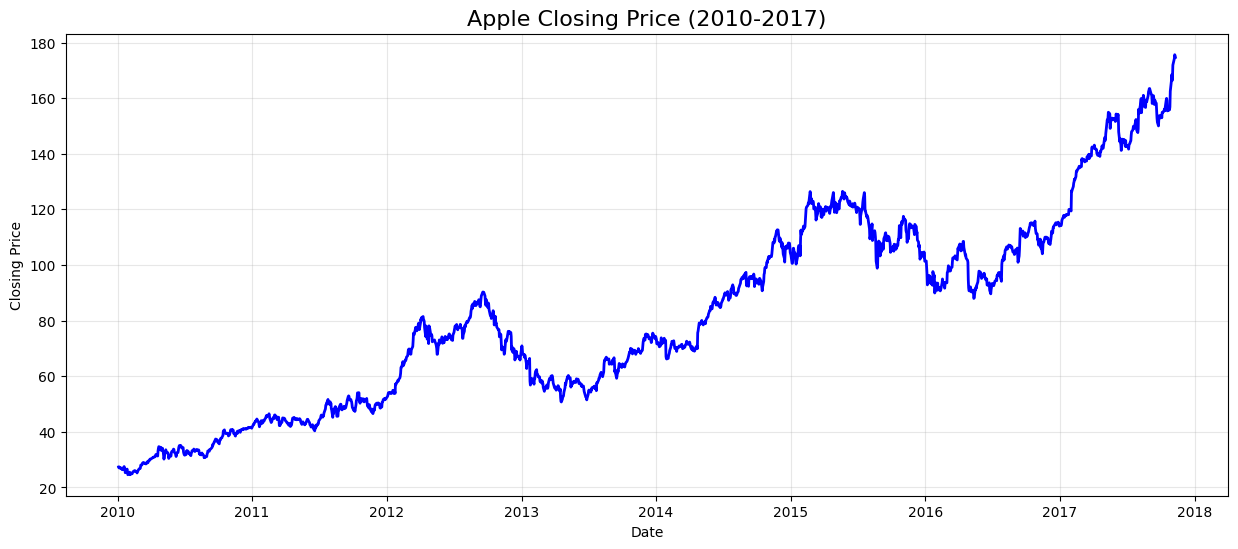

In [119]:
plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Close"],
    color="blue",
    linewidth=2
)

plt.title("Apple Closing Price (2010-2017)", fontsize=16)

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.grid(alpha=0.3)

plt.show()

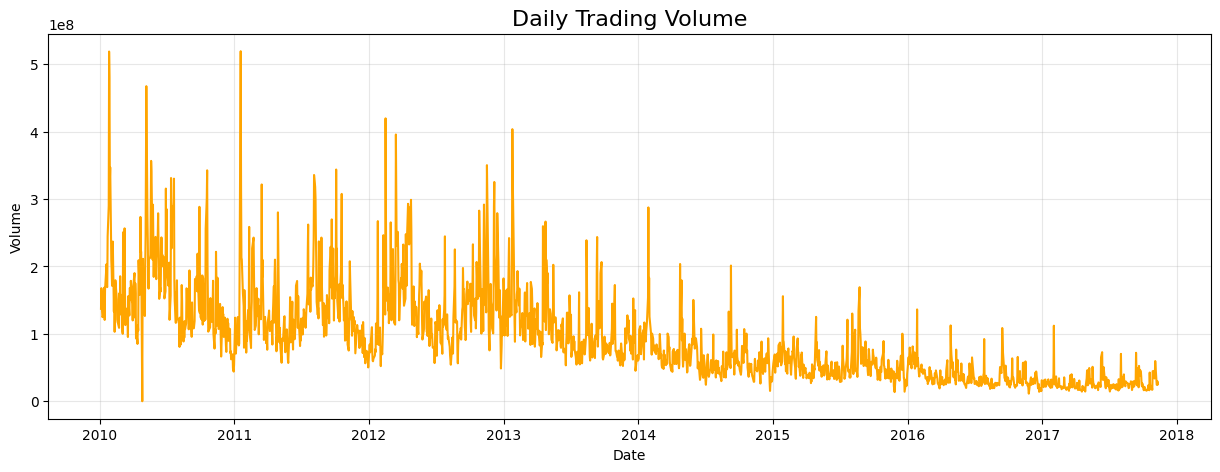

In [120]:
plt.figure(figsize=(15,5))

plt.plot(
    df["Date"],
    df["Volume"],
    color="orange"
)

plt.title("Daily Trading Volume", fontsize=16)

plt.xlabel("Date")

plt.ylabel("Volume")

plt.grid(alpha=0.3)

plt.show()

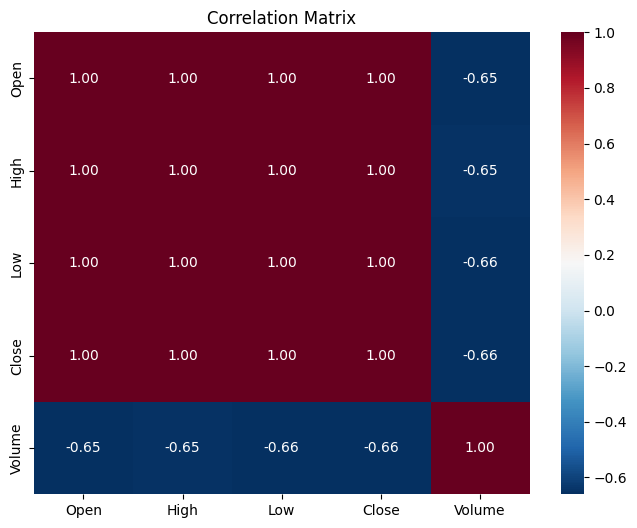

In [121]:
plt.figure(figsize=(8,6))

sns.heatmap(

    df.drop("Date", axis=1).corr(),

    annot=True,

    cmap="RdBu_r",

    fmt=".2f"

)

plt.title("Correlation Matrix")

plt.show()

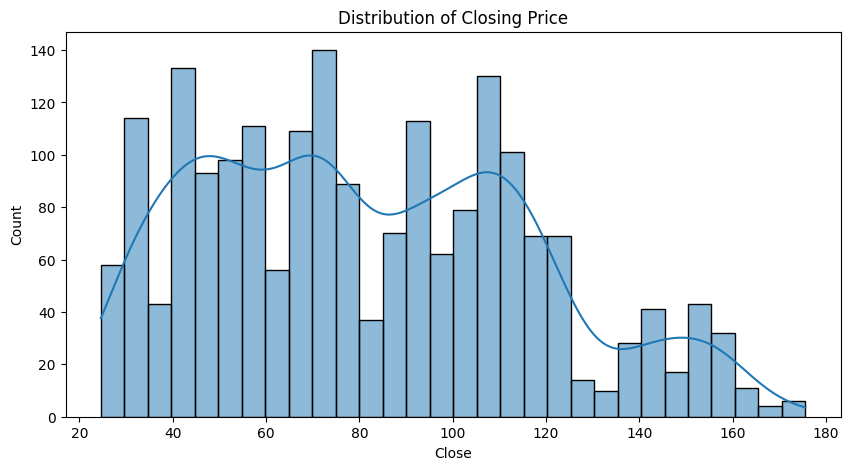

In [122]:
plt.figure(figsize=(10,5))

sns.histplot(

    df["Close"],

    bins=30,

    kde=True

)

plt.title("Distribution of Closing Price")

plt.show()

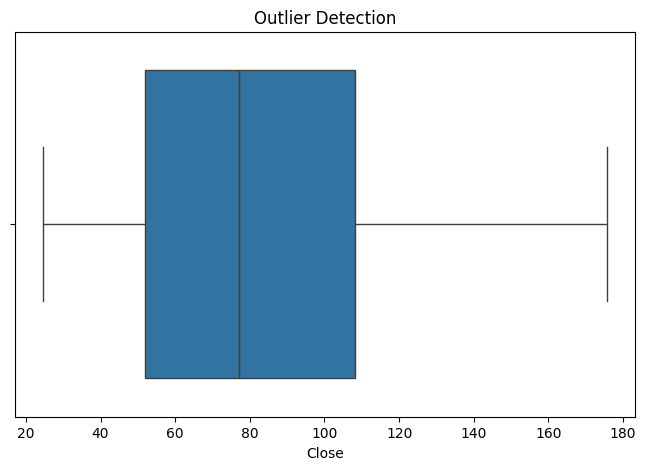

In [123]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Close"])

plt.title("Outlier Detection")

plt.show()

# Feature Engineering

**Purpose**

Feature Engineering is the process of creating new meaningful features from the existing stock market data to improve the prediction capability of machine learning models.

In this section, technical indicators and historical price-based features are created to capture market trends, momentum, and past price behavior.

In [124]:
# Create Working Copy

df_features = df.copy()

print("Working copy created successfully.")

Working copy created successfully.


In [125]:
# Technical Indicators

import ta

# Simple Moving Average (5 Days)
df_features["SMA_5"] = ta.trend.sma_indicator(
    df_features["Close"],
    window=5
)

# Simple Moving Average (20 Days)
df_features["SMA_20"] = ta.trend.sma_indicator(
    df_features["Close"],
    window=20
)

# Exponential Moving Average
df_features["EMA_10"] = ta.trend.ema_indicator(
    df_features["Close"],
    window=10
)

# RSI
df_features["RSI"] = ta.momentum.rsi(
    df_features["Close"],
    window=14
)

# MACD
df_features["MACD"] = ta.trend.macd(
    df_features["Close"]
)

print(" Technical Indicators Created Successfully")

 Technical Indicators Created Successfully


In [126]:
# Lag Features

df_features["Lag_1"] = df_features["Close"].shift(1)

df_features["Lag_2"] = df_features["Close"].shift(2)

df_features["Lag_3"] = df_features["Close"].shift(3)

print("Lag Features Created Successfully")

Lag Features Created Successfully


In [127]:
# Daily Return

df_features["Daily_Return"] = df_features["Close"].pct_change()

print("Daily Return Feature Created Successfully")

Daily Return Feature Created Successfully


In [128]:
# Target Variable

df_features["Target"] = df_features["Close"].shift(-1)

print("Target Variable Created Successfully")

Target Variable Created Successfully


In [129]:
# Remove Missing Values

print("Missing values before cleaning:\n")

print(df_features.isnull().sum())

df_features.dropna(inplace=True)

df_features.reset_index(drop=True, inplace=True)

print("\nMissing values after cleaning:\n")

print(df_features.isnull().sum())

print("\n Missing Values Removed Successfully")

Missing values before cleaning:

Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
SMA_5            4
SMA_20          19
EMA_10           9
RSI             13
MACD            25
Lag_1            1
Lag_2            2
Lag_3            3
Daily_Return     1
Target           1
dtype: int64

Missing values after cleaning:

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
SMA_5           0
SMA_20          0
EMA_10          0
RSI             0
MACD            0
Lag_1           0
Lag_2           0
Lag_3           0
Daily_Return    0
Target          0
dtype: int64

 Missing Values Removed Successfully


In [130]:
print("Final Shape :", df_features.shape)

display(df_features.head())

Final Shape : (1954, 16)


,Date,Open,High,Low,Close,Volume,SMA_5,SMA_20,EMA_10,RSI,MACD,Lag_1,Lag_2,Lag_3,Daily_Return,Target
0,2010-02-09,25.161,25.294,24.938,25.125,176376562,25.0248,25.88220,25.261960,42.066395,-0.576611,24.860,25.032,24.594,0.010660,24.989
1,2010-02-10,25.076,25.177,24.877,24.989,102981576,24.9200,25.80160,25.212331,41.020462,-0.563805,25.125,24.860,25.032,-0.005413,25.441
2,2010-02-11,24.944,25.580,24.853,25.441,153276052,25.0894,25.72475,25.253907,45.840266,-0.511290,24.989,25.125,24.860,0.018088,25.661
3,2010-02-12,25.379,25.823,25.036,25.661,179472736,25.2152,25.66685,25.327924,48.064897,-0.446769,25.441,24.989,25.125,0.008647,26.048
4,2010-02-16,25.862,26.087,25.806,26.048,151049757,25.4528,25.65075,25.458847,51.814383,-0.360255,25.661,25.441,24.989,0.015081,25.939


# Data Preprocessing

**Purpose**

Data preprocessing prepares the dataset for machine learning.

In this section:

- Input features (X) and target variable (y) are selected.
- The dataset is divided into training and testing sets based on time.
- Training data contains historical records (2010–2015).
- Testing data contains future records (2016–2017).

This chronological split prevents data leakage and better simulates real-world stock price prediction.

In [131]:
# Feature Selection

# Input Features
X = df_features.drop(columns=["Date", "Target"])

# Target Variable
y = df_features["Target"]

print("Feature Selection Completed Successfully")

print("\nFeature Shape :", X.shape)
print("Target Shape  :", y.shape)

print("\nFeatures Used:")
print(X.columns.tolist())

Feature Selection Completed Successfully

Feature Shape : (1954, 14)
Target Shape  : (1954,)

Features Used:
['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_5', 'SMA_20', 'EMA_10', 'RSI', 'MACD', 'Lag_1', 'Lag_2', 'Lag_3', 'Daily_Return']


In [132]:
# Time-Based Train-Test Split


train_data = df_features[df_features["Date"] < "2016-01-01"]

test_data = df_features[df_features["Date"] >= "2016-01-01"]

print(" Dataset Split Completed Successfully")

print("\nTraining Samples :", train_data.shape[0])

print("Testing Samples  :", test_data.shape[0])

 Dataset Split Completed Successfully

Training Samples : 1485
Testing Samples  : 469


In [133]:
# Prepare Training Dataset

X_train = train_data.drop(columns=["Date", "Target"])

y_train = train_data["Target"]

X_test = test_data.drop(columns=["Date", "Target"])

y_test = test_data["Target"]

print(" Training and Testing Data Prepared Successfully")

print("\nX_train :", X_train.shape)

print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)

print("y_test  :", y_test.shape)

 Training and Testing Data Prepared Successfully

X_train : (1485, 14)
X_test  : (469, 14)
y_train : (1485,)
y_test  : (469,)


In [134]:
# Verify Date Ranges


print("Training Period")

print(
    train_data["Date"].min(),
    "to",
    train_data["Date"].max()
)

print("\nTesting Period")

print(
    test_data["Date"].min(),
    "to",
    test_data["Date"].max()
)

Training Period
2010-02-09 00:00:00 to 2015-12-31 00:00:00

Testing Period
2016-01-04 00:00:00 to 2017-11-09 00:00:00


# Model Training & Evaluation

**Purpose**

In this section, multiple machine learning regression models are trained using the prepared dataset.

Each model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. The model with the best performance will be selected for further analysis and prediction.

In [135]:
# Import Machine Learning Models


from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

print(" Models Imported Successfully")

 Models Imported Successfully


In [136]:
# Machine Learning Models


models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42,
        max_depth=10
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )
}

print(" Model Dictionary Created Successfully")

 Model Dictionary Created Successfully


In [137]:
# Train and Evaluate Models


results = []
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

    trained_models[name] = model

print("\n All Models Trained Successfully")

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

 All Models Trained Successfully


In [138]:
# Model Comparison

results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]

)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

# Add Ranking
results_df.insert(0, "Rank", range(1, len(results_df) + 1))

# Display the comparison table
display(results_df)

# Save the comparison table
results_df.to_csv("model_comparison.csv", index=False)

print("Model Comparison Saved Successfully")

,Rank,Model,MAE,RMSE,R2 Score
0,1,Linear Regression,1.090388,1.566858,0.995907
1,2,XGBoost,11.465119,17.896982,0.466057
2,3,Random Forest,11.669878,18.185025,0.448732
3,4,Decision Tree,12.372048,18.666270,0.419169


Model Comparison Saved Successfully


In [139]:
# Model Ranking

results_df["Rank"] = range(1, len(results_df) + 1)

results_df = results_df[
    ["Rank", "Model", "MAE", "RMSE", "R2 Score"]
]

results_df

,Rank,Model,MAE,RMSE,R2 Score
0,1,Linear Regression,1.090388,1.566858,0.995907
1,2,XGBoost,11.465119,17.896982,0.466057
2,3,Random Forest,11.669878,18.185025,0.448732
3,4,Decision Tree,12.372048,18.666270,0.419169


In [140]:
# Best Model

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("🏆 Best Model :", best_model_name)

🏆 Best Model : Linear Regression


# Model Evaluation & Visualization

**Purpose**

The performance of the best machine learning model is evaluated using numerical metrics and graphical visualizations.

This section helps us understand:

- How closely the predicted prices match the actual prices.
- The magnitude of prediction errors.
- The overall prediction performance of the selected model.

In [141]:
# Prediction Using Best Model

y_pred = best_model.predict(X_test)

print("Predictions Generated Successfully")

Predictions Generated Successfully


In [142]:
# Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

evaluation = pd.DataFrame({

    "Metric": [
        "Mean Absolute Error",
        "Root Mean Squared Error",
        "R² Score"
    ],

    "Value": [
        round(mae, 3),
        round(rmse, 3),
        round(r2, 4)
    ]

})

# Display the evaluation table
display(evaluation)

# Save the evaluation table
evaluation.to_csv("evaluation_metrics.csv", index=False)

print(" Evaluation Metrics Saved Successfully")

,Metric,Value
0,Mean Absolute Error,1.0900
1,Root Mean Squared Error,1.5670
2,R² Score,0.9959


 Evaluation Metrics Saved Successfully


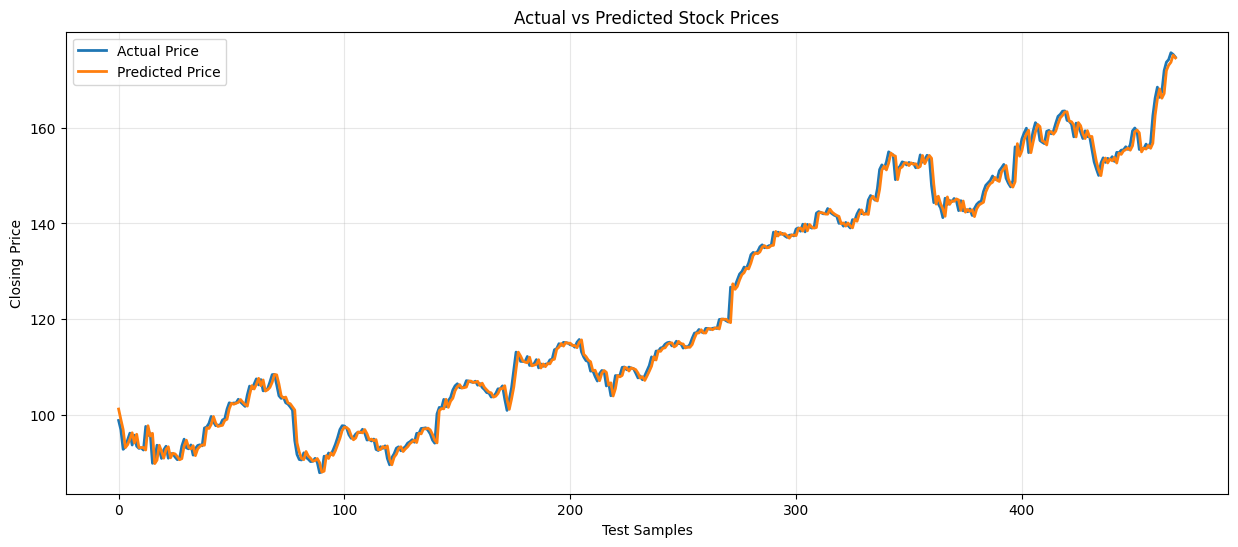

In [143]:
# Actual vs Predicted

plt.figure(figsize=(15,6))

plt.plot(
    y_test.values,
    label="Actual Price",
    linewidth=2
)

plt.plot(
    y_pred,
    label="Predicted Price",
    linewidth=2
)

plt.title("Actual vs Predicted Stock Prices")

plt.xlabel("Test Samples")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

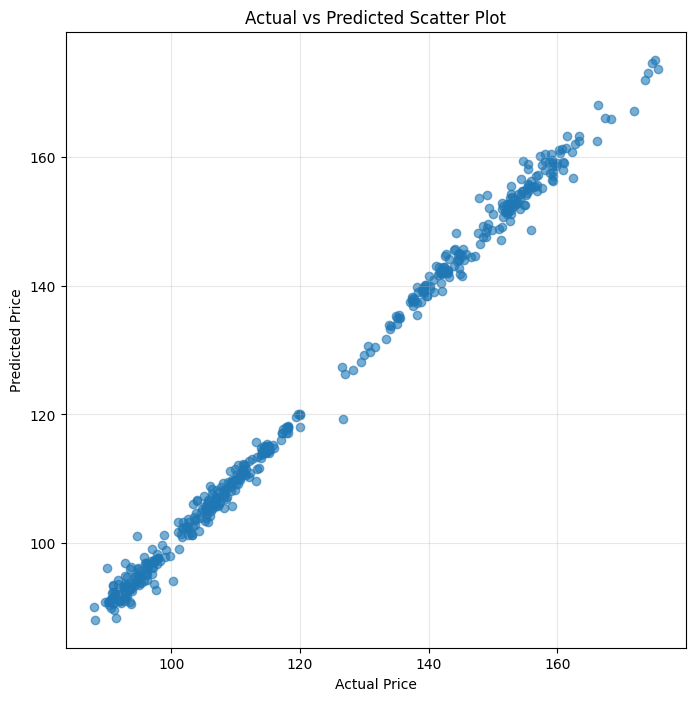

In [144]:
# Scatter Plot


plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Scatter Plot")

plt.grid(alpha=0.3)

plt.show()

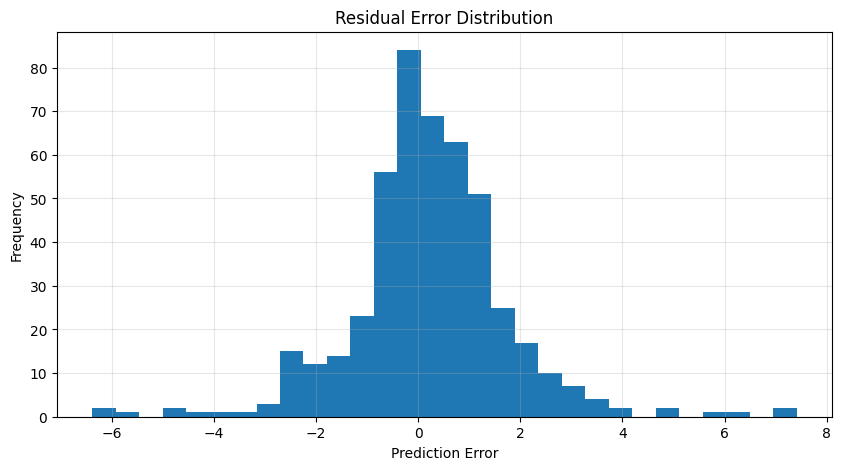

In [145]:
# Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=30
)

plt.title("Residual Error Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [146]:
# Prediction Comparison

comparison = pd.DataFrame({

    "Actual Price": y_test.values,

    "Predicted Price": y_pred

})

comparison.head(10)

,Actual Price,Predicted Price
0,98.885,101.263613
1,96.949,99.074053
2,92.857,96.997425
3,93.349,93.222518
4,94.860,93.836473
5,96.238,95.013135
6,93.762,96.313879
7,95.814,94.185932
8,93.512,96.008031
9,93.059,93.220268


# Save the Best Model

**Purpose**

After selecting the best-performing machine learning model, it is saved to disk using the Joblib library.

Saving the model allows it to be reused later without retraining, making deployment and future predictions more efficient.

In [147]:
# Save Best Model

import joblib

joblib.dump(best_model, "best_stock_price_model.pkl")

print(" Best Model Saved Successfully")

 Best Model Saved Successfully


In [148]:
# Check saved model

loaded_model = joblib.load("best_stock_price_model.pkl")

print(" Model Loaded Successfully")

 Model Loaded Successfully


# Predict Next Trading Day Closing Price

**Purpose**

The trained model is used to predict the closing price for the next trading day using the most recent available stock market data.

In [149]:
# Next Day Prediction

latest_data = X.iloc[[-1]]

predicted_price = loaded_model.predict(latest_data)

print("Predicted Next Day Closing Price")

print(f"${predicted_price[0]:.2f}")

Predicted Next Day Closing Price
$174.52


In [150]:
latest_data

,Open,High,Low,Close,Volume,SMA_5,SMA_20,EMA_10,RSI,MACD,Lag_1,Lag_2,Lag_3,Daily_Return
1953,174.48,175.46,172.52,175.25,29533086,174.11,163.608,170.182995,77.088115,4.89402,175.61,174.18,173.63,-0.00205


# Conclusion

In this project, a machine learning pipeline was developed to predict the next trading day's closing price of Apple Inc. using historical stock market data.

The dataset was cleaned, analyzed, and enhanced using technical indicators such as SMA, EMA, RSI, MACD, lag features, and daily returns.

Multiple regression algorithms including Linear Regression, Decision Tree, Random Forest, and XGBoost were trained and evaluated.

Among all the models, Linear Regression achieved the highest performance with:

- Mean Absolute Error (MAE): 1.09
- Root Mean Squared Error (RMSE): 1.57
- R² Score: 0.9959

The results indicate that the developed model can accurately estimate the next trading day's closing price for the selected dataset.

# Future Scope

**Future Improvements**

This project can be enhanced further by:

- Using real-time stock market data through financial APIs.
- Training deep learning models such as LSTM or GRU.
- Including news sentiment analysis and economic indicators.
- Building a web application using Streamlit or Flask.
- Deploying the model on cloud platforms for real-time prediction.

# References
1. Yahoo Finance Historical Stock Data
2. Kaggle Stock Market Dataset
3. Scikit-learn Documentation
4. XGBoost Documentation
5. TA (Technical Analysis) Python Library Documentation